In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import optuna
import math
from tqdm import tqdm

from position_tools import calculate_trades, calculate_positions
optuna.logging.set_verbosity(optuna.logging.ERROR)

In [5]:
def load_json_candles(fname):
    data = pd.read_json(fname)
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

def load_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/{base}_{quote}-{timeframe}.json'
    return load_json_candles(fname)

def load_futures_candles(exchange,base,quote,timeframe):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/{exchange}/futures/{base}_{quote}_{quote}-{timeframe}-futures.json'
    return load_json_candles(fname)

def load_sp500_stock_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/sp500_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

def load_russel2000_candles(ticker):
    fname = f'/media/mu6mula/Data/Crypto-Data-Feed/russell_2000_data/{ticker}.csv'
    data = pd.read_csv(fname)
    data['Date'] = pd.to_datetime(data.Date)
    data.columns = [c.lower() for c in data.columns]
    data.set_index('date', inplace=True)
    return data

In [6]:
params = {'tenkan_period': 17, 'kijun_period': 43, 'senkou_span_b_period': 94}

params = {'tenkan_period': 34, 'kijun_period': 132, 'senkou_span_b_period': 138}
Total Return: 12.25
Sharpe Ratio: 0.07
# Trades: 54
# Wins: 15
# Losses: 39
Win Ratio: 0.28
Profit Factor: 3.93
Win Ratio: 0.28
Average Win: 0.5056
Average Loss: -0.0494
Average DrawDown: -0.1617
Max Trade DrawDown: -0.5733


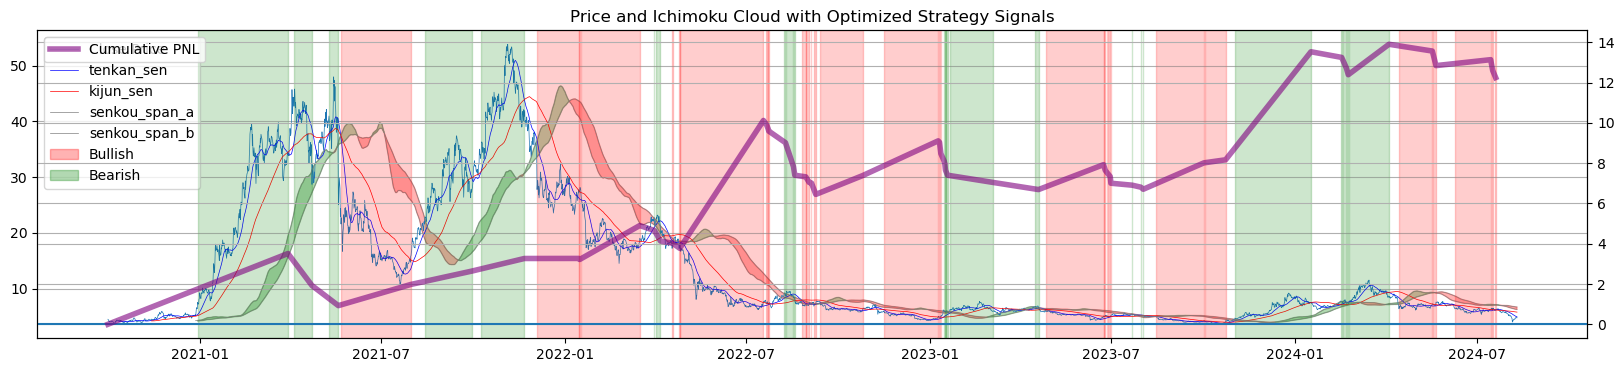

params = {'tenkan_period': 65, 'kijun_period': 85, 'senkou_span_b_period': 143}
Total Return: 7.24
Sharpe Ratio: 0.08
# Trades: 90
# Wins: 20
# Losses: 70
Win Ratio: 0.22
Profit Factor: 3.43
Win Ratio: 0.22
Average Win: 0.4923
Average Loss: -0.0410
Average DrawDown: -0.3387
Max Trade DrawDown: -0.6334


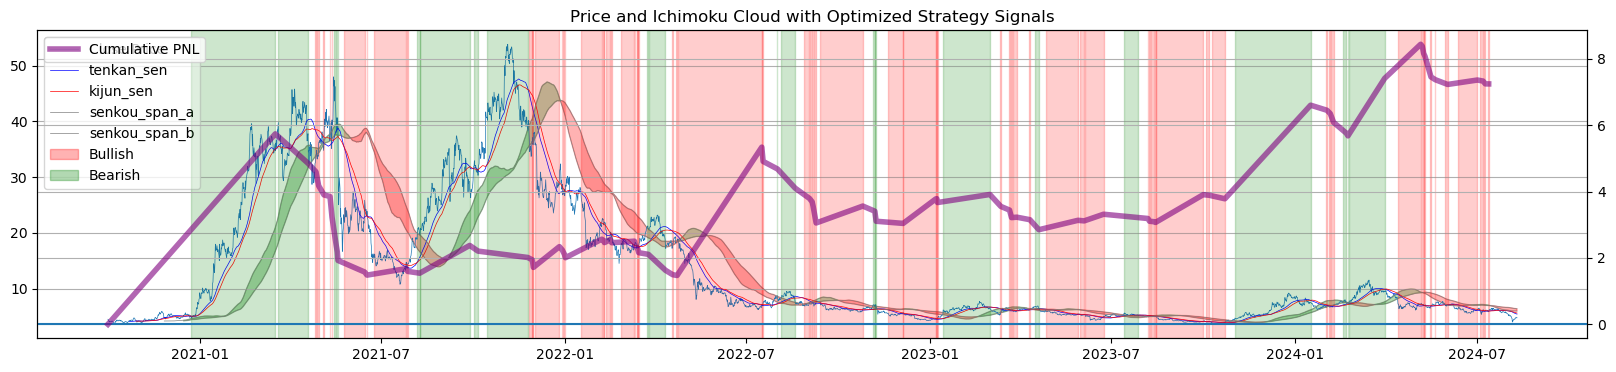

params = {'tenkan_period': 33, 'kijun_period': 157, 'senkou_span_b_period': 182}
Total Return: 9.16
Sharpe Ratio: 0.06
# Trades: 41
# Wins: 13
# Losses: 28
Win Ratio: 0.32
Profit Factor: 3.87
Win Ratio: 0.32
Average Win: 0.3617
Average Loss: -0.0433
Average DrawDown: -0.0820
Max Trade DrawDown: -0.3109


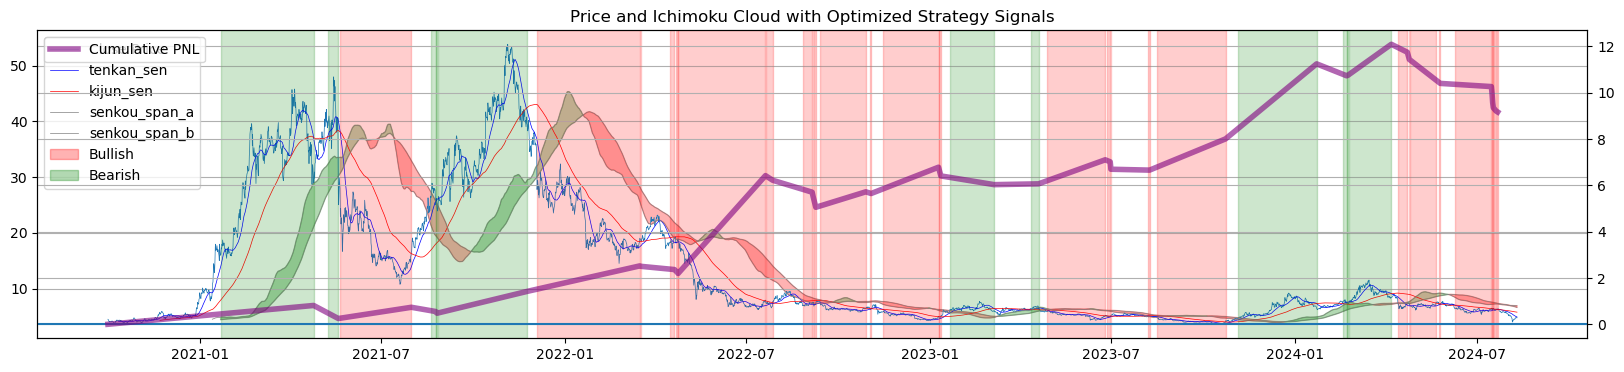

params = {'tenkan_period': 27, 'kijun_period': 50, 'senkou_span_b_period': 151}
Total Return: 17.64
Sharpe Ratio: 0.09
# Trades: 97
# Wins: 28
# Losses: 69
Win Ratio: 0.29
Profit Factor: 2.77
Win Ratio: 0.29
Average Win: 0.2752
Average Loss: -0.0403
Average DrawDown: -0.1741
Max Trade DrawDown: -0.6882


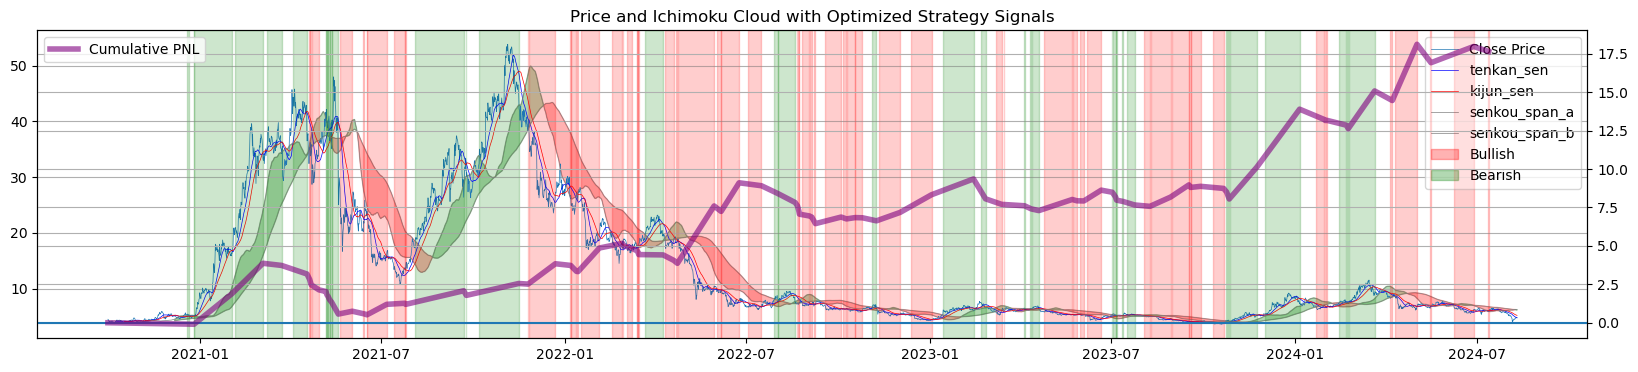

params = {'tenkan_period': 70, 'kijun_period': 81, 'senkou_span_b_period': 78}
Total Return: 20.06
Sharpe Ratio: 0.08
# Trades: 80
# Wins: 22
# Losses: 58
Win Ratio: 0.28
Profit Factor: 3.82
Win Ratio: 0.28
Average Win: 0.4519
Average Loss: -0.0449
Average DrawDown: -0.1521
Max Trade DrawDown: -0.6015


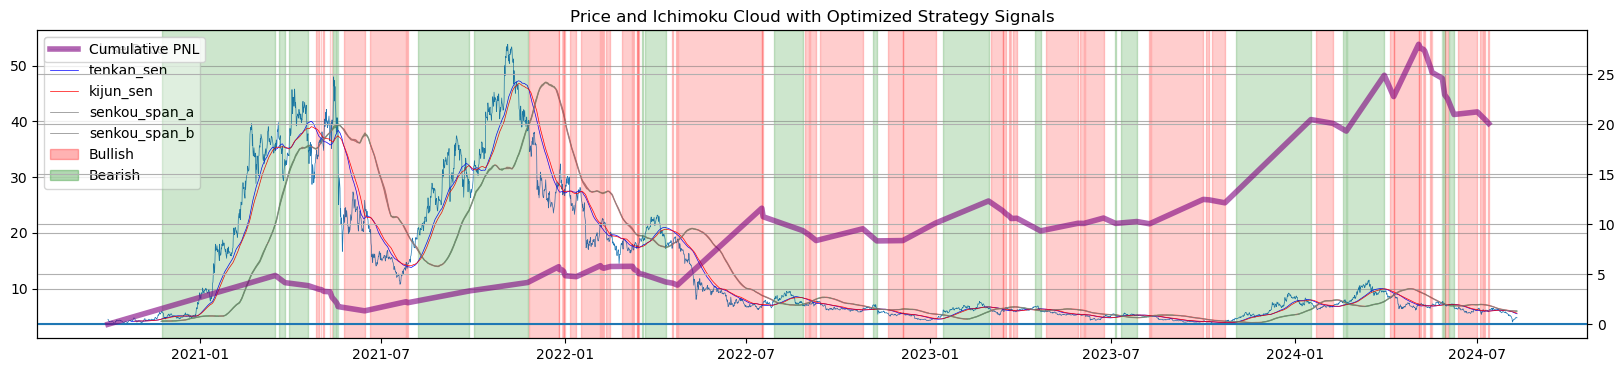

params = {'tenkan_period': 35, 'kijun_period': 58, 'senkou_span_b_period': 79}
Total Return: 13.37
Sharpe Ratio: 0.09
# Trades: 97
# Wins: 27
# Losses: 70
Win Ratio: 0.28
Profit Factor: 3.06
Win Ratio: 0.28
Average Win: 0.3694
Average Loss: -0.0466
Average DrawDown: -0.2836
Max Trade DrawDown: -0.7862


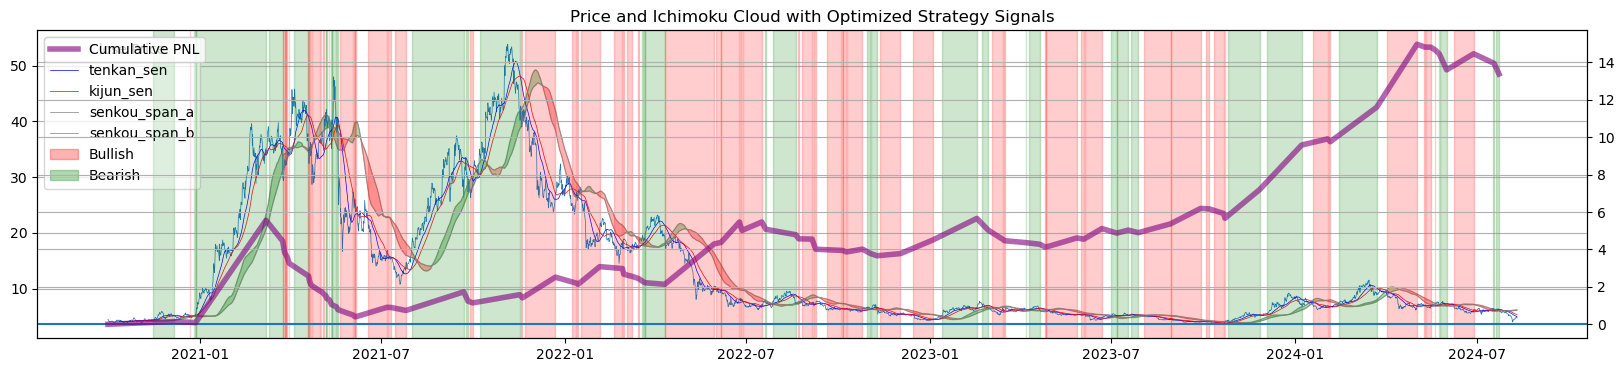

params = {'tenkan_period': 22, 'kijun_period': 46, 'senkou_span_b_period': 34}
Total Return: 21.21
Sharpe Ratio: 0.10
# Trades: 119
# Wins: 41
# Losses: 78
Win Ratio: 0.34
Profit Factor: 2.56
Win Ratio: 0.34
Average Win: 0.2037
Average Loss: -0.0418
Average DrawDown: -0.1362
Max Trade DrawDown: -0.4923


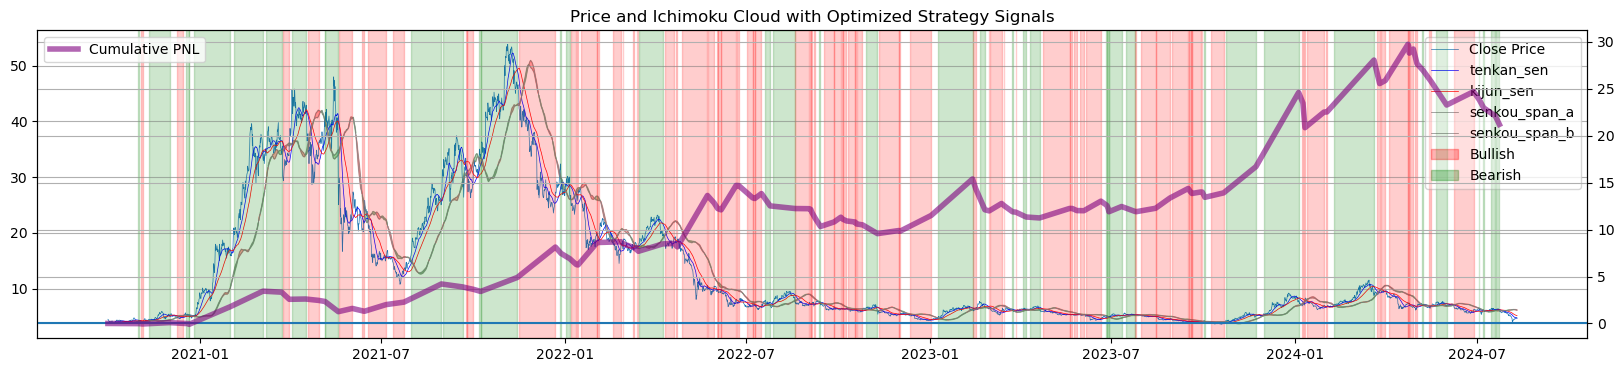

In [142]:

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.003  # 0.1% slippage per trade



# Define the fitness function
# def calculate_indicators(data, params):
def backtest(data, params, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]
    lclose = data['lclose']
    lrets = data['lrets']
    
    tenkan_period = params['tenkan_period']
    kijun_period = params['kijun_period']
    senkou_span_b_period = params['senkou_span_b_period']
    
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)

    bull = (
        (data['close'] > data['senkou_span_a']) &\
        (data['close'] > data['senkou_span_b']) &\
        (data['tenkan_sen'] > data['kijun_sen']) &\
        (data['close'] > data['kijun_sen'])
    )
                  
    bull_end = ((data['close'] < data['senkou_span_a']) |\
        (data['close'] < data['senkou_span_b'])) |\
        (data['close'] < data['kijun_sen']) &\
        (data['tenkan_sen'] < data['kijun_sen']) &\
        (data['close'] < data['kijun_sen'])
                        
    
    bear = (
        (data['close'] < data['senkou_span_a']) &\
        (data['close'] < data['senkou_span_b']) &\
        (data['tenkan_sen'] < data['kijun_sen']) &\
        (data['close'] < data['kijun_sen'])
    )
                  
    bear_end = ((data['close'] > data['senkou_span_a']) |\
        (data['close'] > data['senkou_span_b'])) |\
        (data['close'] > data['kijun_sen']) &\
        (data['senkou_span_a'] > data['senkou_span_b']) |\
        (data['close'] > data['kijun_sen'])
                            

    # Initialize the 'position' column
   
    itrades = calculate_trades(int(1 in short_long)*bull.values, int(1 in short_long)*bull_end.values, int(-1 in short_long)*bear.values, int(-1 in short_long)*bear_end.values)
    ipositions = calculate_positions(itrades,len(lclose))

    # strat_rets = positions * lrets.shift()

    entry_points = data.index[itrades[:,0]]
    exit_points = data.index[itrades[:,1]]
    trade_rets = xmult*pd.Series(np.append([0],itrades[:,2]*(lclose.values[itrades[:,1]] - lclose.values[itrades[:,0]])), index=data.index[np.append([0],itrades[:,1])])
    trade_pnl = trade_rets.cumsum()
    strat_rets = lrets.shift() * ipositions
    strat_pnl = strat_rets.cumsum()
    
    n_trades = len(itrades)
    # strat_rets -= data['trade'].abs() * (transaction_cost + slippage)
    data['strat_pnl'] = strat_pnl
    
    ###
    strat_rets_pct = np.exp(strat_rets) - 1
    trade_rets_pct = np.exp(trade_rets) - 1
    strat_pnl_pct = np.exp(strat_pnl) - 1
    # trade_pnl_pct = np.exp(trade_pnl) - 1
    trade_pnl_pct = (trade_rets_pct + 1).cumprod() - 1
    # Calculate performance metrics
    tot_return = trade_pnl.iloc[-1]
    wins = trade_rets_pct[trade_rets_pct > 0];  
    losses = trade_rets_pct[trade_rets_pct < 0]
    nwins, nlosses = len(wins), len(losses)
    win_ratio = nwins/ (n_trades) if n_trades > 0 else np.nan
    profit_factor = wins.sum() / losses.abs().sum()
    strat_rets_mean = strat_rets_pct.mean()
    sharpe = strat_rets_mean / strat_rets_pct.std()
    sortino = strat_rets_mean / losses.std()
    avg_win = wins.mean() if len(wins) > 0 else np.nan
    avg_loss = losses.mean() if len(losses) > 0 else np.nan
    
    trade_running_max = trade_pnl.cummax()
    trade_drawdowns = (trade_pnl - trade_running_max)
    trade_max_drawdown = np.min(trade_drawdowns)
    trade_drawdowns_pct = np.exp(trade_drawdowns) - 1
    trade_max_drawdown_pct = np.min(trade_drawdowns_pct)
       
    return {'tot_return':tot_return, 
            'n_trades': n_trades, 
            'nwins':nwins, 'nlosses': nlosses, 'win_ratio': win_ratio, 'profit_factor': profit_factor, 
            'sharpe': sharpe, 'sortino': sortino, 
            'entry_points': entry_points, 'exit_points': exit_points, 
            'trade_rets': trade_rets, 'trade_pnl': trade_pnl, 'strat_rets': strat_rets, 'strat_pnl': strat_pnl, 
            'trade_rets_pct': trade_rets_pct, 'trade_pnl_pct': trade_pnl_pct, 'strat_rets_pct': strat_rets_pct, 'strat_pnl_pct': strat_pnl_pct, 
            'itrades': itrades,
            'avg_win': avg_win, 'avg_loss': avg_loss,
            'trade_max_drawdown': trade_max_drawdown, 'trade_drawdowns': trade_drawdowns,
            'trade_max_drawdown_pct': trade_max_drawdown_pct, 'trade_drawdowns_pct': trade_drawdowns_pct
            # 'trade_details': trade_details 
    }   


def optimize(data, nhours, backtest_fn = backtest, short_long=None, xmult=1, opt_res='sharpe'):
    # Define the objective function for Optuna
    def objective(trial):
        global data
        tenkan_period = trial.suggest_int('tenkan_period', 20, 100)
        kijun_period = trial.suggest_int('kijun_period', tenkan_period+10, 200)
        senkou_span_b_period = trial.suggest_int('senkou_span_b_period', tenkan_period, 200)
        params = {
            'tenkan_period': tenkan_period,
            'kijun_period': kijun_period,
            'senkou_span_b_period': senkou_span_b_period
        }
        
        res = backtest_fn(data,params,nhours,short_long, xmult=xmult)
        return res['sharpe'], res['trade_drawdowns_pct'].mean()#/ math.cos(number_of_trades)

    # Run the optimization
    study = optuna.create_study(directions=['maximize','maximize'])
    study.optimize(objective, n_trials=50)

    # Get the best parameters
    return study
    

def print_performance(data, nhours, best_params, backtest_fn, short_long=None, xmult=1):
    # indicators(data, best_params)
    res = backtest_fn(data,params, nhours,short_long=short_long,xmult=xmult)
    itrades = res['itrades']
    # trade_stats(data)
    
    print_res(res)
    # Plot the results with the best parameters
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 7), sharex=True, height_ratios=[2, 1])
    fig, (ax1) = plt.subplots(figsize=(20, 4))

    ax1.plot(data.index, data['close'], label='Close Price', lw=0.5)
    ax1.plot(data.index, data['tenkan_sen'], label='tenkan_sen', color='blue', lw=0.5)
    ax1.plot(data.index, data['kijun_sen'], label='kijun_sen', color='red', lw=0.5)
    ax1.plot(data.index, data['senkou_span_a'], label='senkou_span_a', color='gray', lw=0.5)
    ax1.plot(data.index, data['senkou_span_b'], label='senkou_span_b', color='gray', lw=0.5)
    # ax1.scatter(res['entry_points'], data.loc[entry_points, 'close'], marker='^', color='g', s=30, label='Entry', zorder=5, alpha=0.3)
    # ax1.scatter(exit_points, data.loc[exit_points, 'close'], marker='v', color='r', s=30, label='Exit', zorder=5, alpha=0.3)
    ax1.fill_between(data.index, data['senkou_span_a'], data['senkou_span_b'], where=(data['senkou_span_a'] < data['senkou_span_b']), color='red', alpha=0.3, label='Bullish')
    ax1.fill_between(data.index, data['senkou_span_a'], data['senkou_span_b'], where=(data['senkou_span_a'] > data['senkou_span_b']), color='green', alpha=0.3, label='Bearish')
    ax1.legend(loc='best')
    ax1.grid(axis='y')
    plt.title('Price and Ichimoku Cloud with Optimized Strategy Signals')

    ax2 = ax1.twinx()
    ax2.axhline(0)
    # ax2.plot(res['strat_pnl_pct'], label='Unrealized PNL', color='blue', alpha=0.3)
    ax2.plot(res['trade_pnl_pct'], label='Cumulative PNL', color='purple', alpha=0.6, lw=4)
    
    ax2.legend(loc='best')
    # for x in res['entry_points'].values: 
    #     ax1.axvline(x,color='black', lw=3, alpha=0.1)
    #     ax2.axvline(x,color='black', lw=3, alpha=0.1)
    # for xx in res['exit_points'].values:
    #     ax1.axvline(xx,color='red', lw=1, alpha=0.1)
    #     ax2.axvline(xx,color='red', lw=1, alpha=0.1)
    for i in range(len(itrades)):
        ax1.axvspan(xmin=data.index[itrades[i,0]],xmax=data.index[itrades[i,1]], color=['red','green'][(itrades[i,2]+1)//2],alpha=0.1)
        ax2.axvspan(xmin=data.index[itrades[i,0]],xmax=data.index[itrades[i,1]], color=['red','green'][(itrades[i,2]+1)//2],alpha=0.1)
        
    ax2.grid(axis='y')
    
    plt.show()

    return res
    
def print_res(res):
    # Print performance metrics
    print(f"Total Return: {np.exp(res['tot_return'])-1:.2f}")
    print(f"Sharpe Ratio: {res['sharpe']:.2f}")
    print(f"# Trades: {res['n_trades']:.0f}")
    print(f"# Wins: {res['nwins']:.0f}")
    print(f"# Losses: {res['nlosses']:.0f}")
    print(f"Win Ratio: {res['win_ratio']:.2f}")
    print(f"Profit Factor: {res['profit_factor']:.2f}")
    print(f"Win Ratio: {res['win_ratio']:.2f}")
    # print(f"Annualized Return: {results['annualized_return']:.2f}")
    print(f"Average Win: {res['avg_win']:.4f}")
    print(f"Average Loss: {res['avg_loss']:.4f}")
    print(f"Average DrawDown: {res['trade_drawdowns_pct'].mean():.4f}")
    print(f"Max Trade DrawDown: {res['trade_max_drawdown_pct']:.4f}")
# Load the data
# ticker = 'GOOGL'
# data = load_sp500_stock_candles(ticker)['2020':'2025']
# data['close'] = data['adj close']
# data = load_russel2000_candles('XOXO')['2006':]
data = load_candles('binance','DOT','USDT','1h')['2020-10':'2025']#.iloc[-5000:]
# # data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# # data = data['2021-11-01':].copy()
nhours = 8
data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
data = data.assign(lclose=lambda d: d['close'].apply(np.log)).assign(lrets=lambda d:d['lclose'].diff())
short_long = [1,-1]
# study = optimize(data, nhours,backtest_fn=backtest, short_long=short_long)
# aparams = [{'up_lookback': 33, 'dn_lookback': 61, 'up_lag': 6, 'dn_lag': 5}]
aparams = [t.params for t in reversed(study.best_trials[-10:])]
for params in aparams:
    print(f'params = {params}')
    print_performance(data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)

In [109]:
res['itrades']

array([[117, 266,   1],
       [270, 272,  -1],
       [273, 281,  -1],
       [282, 331,  -1],
       [340, 344,  -1],
       [348, 349,  -1],
       [350, 351,  -1],
       [370, 373,   1],
       [375, 391,   1],
       [430, 491,   1]], dtype=int32)

In [102]:
strat_pnl_pct = res['strat_pnl_pct']
strat_pnl_pct[strat_pnl_pct != 0].shape

(2985,)

## Split data into training and testing set

In [43]:
np.min([params[k] for k in params])

78

params = {'tenkan_period': 20, 'kijun_period': 33, 'senkou_span_b_period': 21}


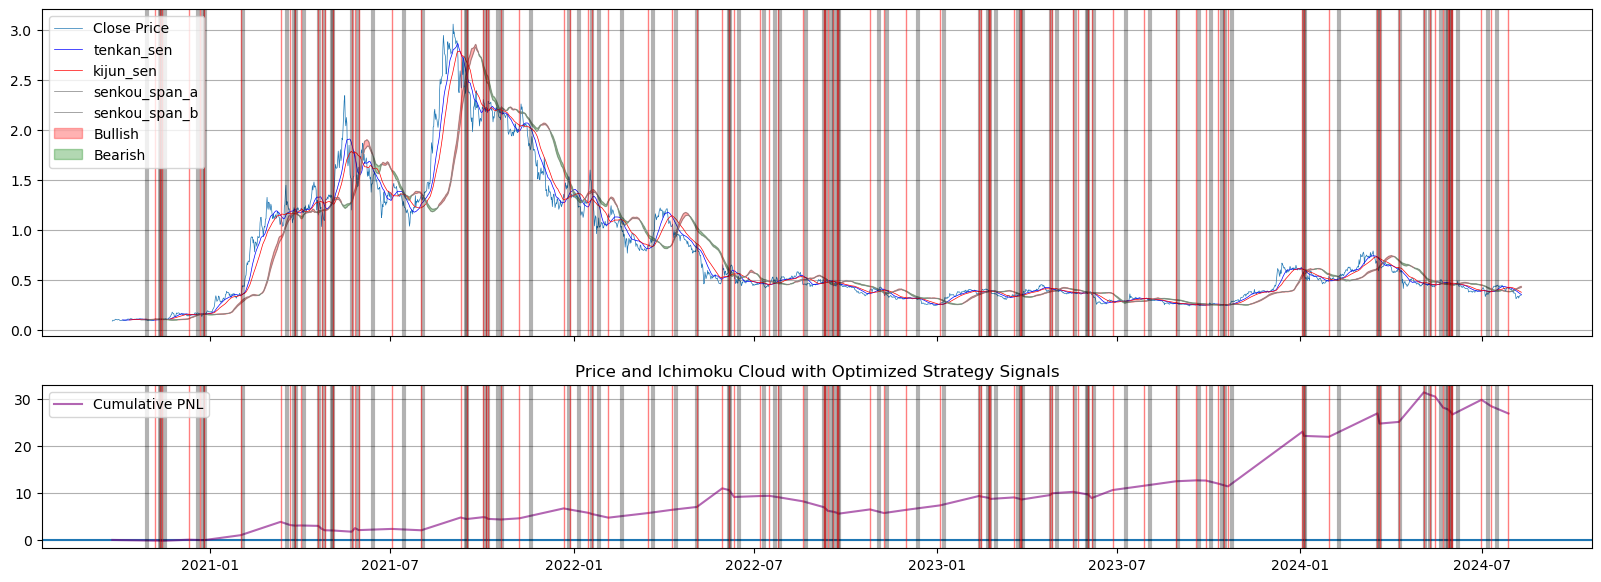

Sharpe Ratio: 0.11
Total Return: 3.33
Number of Trades: 90
Win Ratio: 0.37


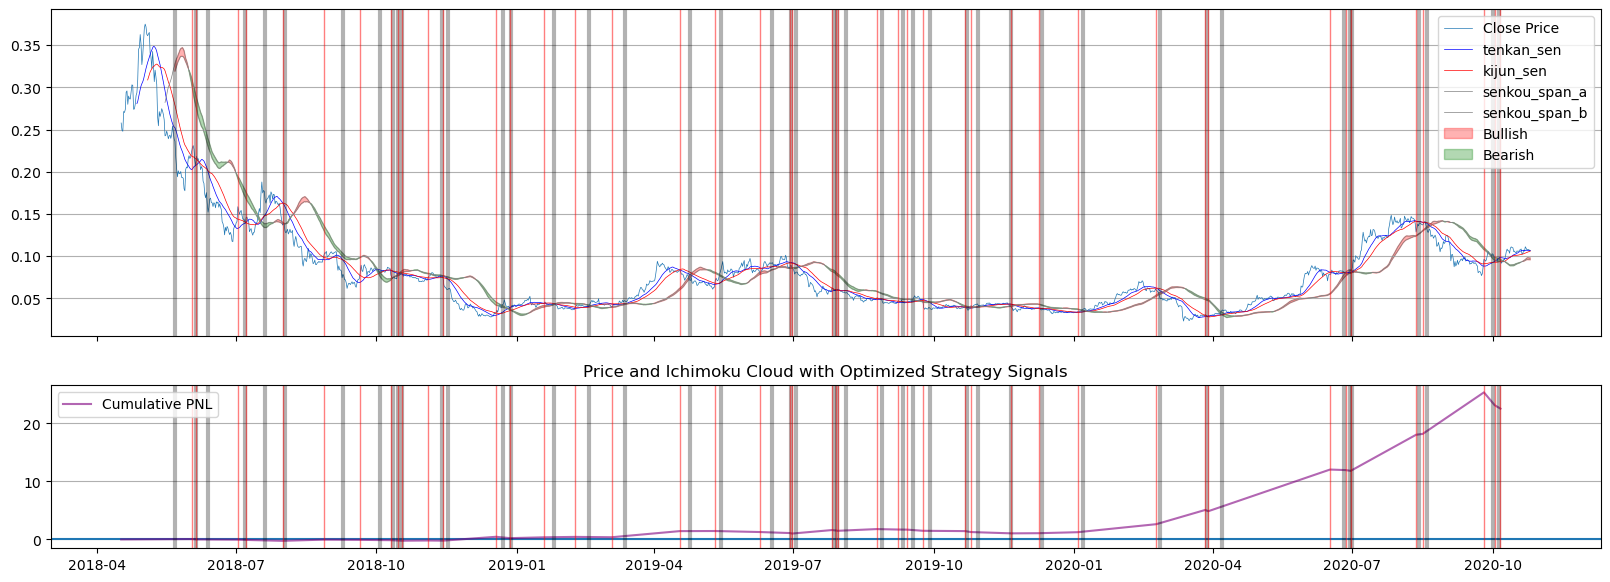

Sharpe Ratio: 0.11
Total Return: 3.16
Number of Trades: 45
Win Ratio: 0.40
params = {'tenkan_period': 20, 'kijun_period': 33, 'senkou_span_b_period': 21}


In [89]:

data = load_candles('binance','ADA','USDT','1h')#.iloc[-5000:]
# data = load_futures_candles('bybit','ALGO','USDT','1h')['2020-03':'2025']
# data = data['2021-11-01':].copy()
nhours = 13
data = data.resample(f'{nhours}H').agg( {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
data = data.assign(lclose=lambda d: d['close'].apply(np.log)).assign(lrets=lambda d:d['lclose'].diff())
short_long = [-1,1]

train_ratio = 0.4; 
cutoff = int(train_ratio * data.shape[0])
train_data, test_data = data.iloc[:cutoff,:], data.iloc[cutoff+1-np.max([params[k] for k in params]):,:]

study = optimize(train_data, nhours,backtest_fn=backtest, short_long=short_long)
params = study.best_params
# params = {'tenkan_period': 19, 'kijun_period': 22, 'senkou_span_b_period': 22}
print(f'params = {params}')
print_performance(test_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print_performance(train_data,nhours,params,backtest_fn=backtest,short_long=short_long, xmult=1)
print(f'params = {params}')

In [27]:
train_data

,open,high,low,close,volume
timestamp,,,,,
2019-02-19 08:00:00,0.01950,0.01956,0.01833,0.01926,32993749.5
2019-02-19 16:00:00,0.01924,0.01950,0.01865,0.01868,19018997.0
2019-02-20 00:00:00,0.01868,0.01884,0.01796,0.01838,16758973.6
2019-02-20 08:00:00,0.01839,0.01900,0.01829,0.01855,12305431.4
2019-02-20 16:00:00,0.01858,0.01954,0.01842,0.01888,10684088.6
...,...,...,...,...,...
2021-04-27 00:00:00,0.16455,0.17526,0.16051,0.17177,63241051.1
2021-04-27 08:00:00,0.17177,0.21700,0.17172,0.20148,484372901.2
2021-04-27 16:00:00,0.20172,0.21674,0.19551,0.21270,213894086.7


## VectorBT Backtesting

In [ ]:
# import vectorbt as vbt

In [71]:
import vectorbt as vbt
# import kaleido
vbt.settings.portfolio['init_cash'] = 100.  # 100$
vbt.settings.portfolio['fees'] = 0.002# 0.25%
vbt.settings.portfolio['slippage'] = 0.0025  # 0.25%

data = load_candles('binance','ADA','USDT','8h')
# nhours = 18
# data = data.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
params = {'tenkan_period': 15, 'kijun_period': 47, 'senkou_span_b_period': 30}
indicators(data, params)


buys = data['bull']
sells = data['bull_exit'] 

# buys = (data['bull'] & ~data['bull'].shift(fill_value=0)) 
# sells = data['bull_exit']  &~data['bull_exit'].shift(fill_value=0) 
portfolio = vbt.Portfolio.from_signals(data['close'], buys, sells, init_cash=100)
portfolio.stats()



Start                                2020-01-01 00:00:00
End                                  2024-08-08 08:00:00
Period                                1681 days 16:00:00
Start Value                                        100.0
End Value                                      338.96186
Total Return [%]                               238.96186
Benchmark Return [%]                          -45.458758
Max Gross Exposure [%]                             100.0
Total Fees Paid                                79.537286
Max Drawdown [%]                               84.811957
Max Drawdown Duration                 1272 days 16:00:00
Total Trades                                          58
Total Closed Trades                                   58
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Rate [%]                                   18.965517
Best Trade [%]                                 184.30539
Worst Trade [%]                

## Backtrader

In [35]:

import backtrader as bt
import backtrader.analyzers as btanalyzers
import backtrader.feeds as btfeeds
import backtrader.strategies as btstrats

In [56]:

data = load_candles('binance','ALGO','USDT','1h')
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 18
data = data.resample(f'{nhours}H').agg(ohlc_dict)
params = {'tenkan_period': 43, 'kijun_period': 34, 'senkou_span_b_period': 33}
indicators(data,params)
data['signal'] = (data['bull'] &~data['bull'].shift(fill_value=False)).astype(int) - (data['bull_exit'] &~data['bull_exit'].shift(fill_value=False)).astype(int) #- data['bear'].astype(int) + data['bear_exit'].astype(int)

init_cash = 100
fees = 0.075 # in %
list(enumerate(data.columns))

[(0, 'open'),
 (1, 'high'),
 (2, 'low'),
 (3, 'close'),
 (4, 'volume'),
 (5, 'lclose'),
 (6, 'tenkan_sen'),
 (7, 'kijun_sen'),
 (8, 'senkou_span_a'),
 (9, 'senkou_span_b'),
 (10, 'bull'),
 (11, 'bull_exit'),
 (12, 'bear'),
 (13, 'bear_exit'),
 (14, 'signal')]

In [52]:
data.bull

timestamp
2020-01-01 00:00:00    False
2020-01-01 18:00:00    False
2020-01-02 12:00:00    False
2020-01-03 06:00:00    False
2020-01-04 00:00:00    False
                       ...  
2024-08-05 12:00:00    False
2024-08-06 06:00:00    False
2024-08-07 00:00:00    False
2024-08-07 18:00:00    False
2024-08-08 12:00:00    False
Freq: 18h, Name: bull, Length: 2243, dtype: bool

Sharpe Ratio: OrderedDict([('sharperatio', -17.99069056221375)])
Returns: OrderedDict([('rtot', 0.002189601072992579), ('ravg', 1.3017842288897617e-06), ('rnorm', 0.0003281034398430855), ('rnorm100', 0.03281034398430855)])


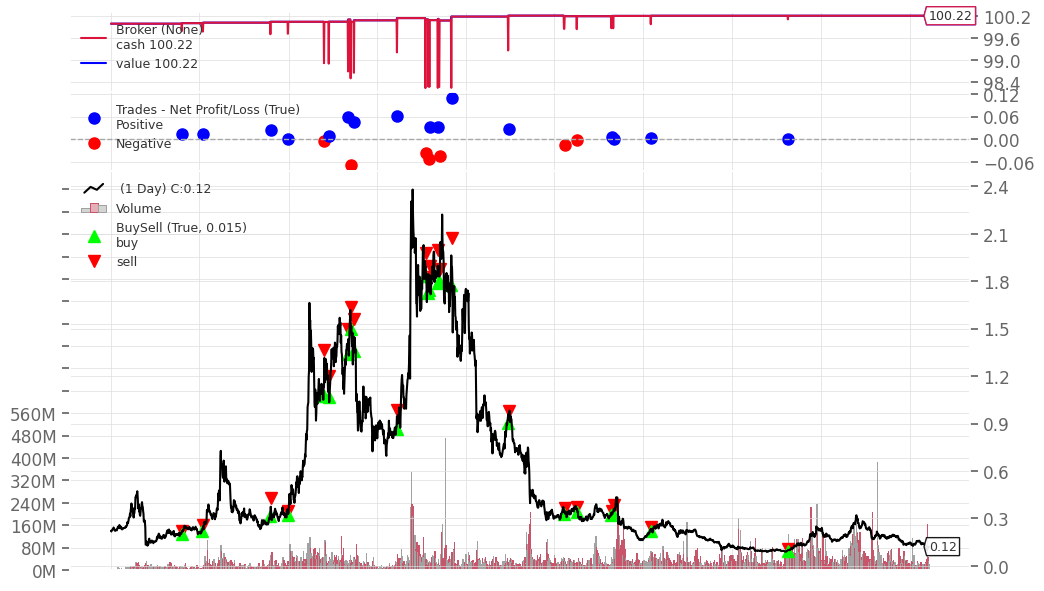

AutoOrderedDict([('total',
                  AutoOrderedDict([('total', 23),
                                   ('open', 0),
                                   ('closed', 23)])),
                 ('streak',
                  AutoOrderedDict([('won',
                                    AutoOrderedDict([('current', 4),
                                                     ('longest', 4)])),
                                   ('lost',
                                    AutoOrderedDict([('current', 0),
                                                     ('longest', 2)]))])),
                 ('pnl',
                  AutoOrderedDict([('gross',
                                    AutoOrderedDict([('total',
                                                      0.21920000000000017),
                                                     ('average',
                                                      0.009530434782608703)])),
                                   ('net',
                        

In [64]:
import matplotlib.pyplot as plt
from pprint import pprint
%matplotlib inline

class PandasData(bt.feeds.PandasData):
    # Add a 'signal' line to the inherited lines from the base class 'PandasData'
    lines = ('signal',)

    # Define parameters for the added line
    params = (('signal', 14),)  # Default index 7 for 'Signal' column in the DataFrame

# Create a data feed from your Pandas DataFrame
data_feed = PandasData(dataname=data)

class MyStrategy(bt.Strategy):
    def __init__(self):
        self.signal = self.data.signal

    def next(self):
        if self.signal[0] == 1:
            if not self.position:  # Not in the market
                self.buy()
        elif self.signal[0] == 0:
            if self.position:  # In the market
                self.close()

# Instantiate Cerebro engine
cerebro = bt.Cerebro()

# Add your strategy
cerebro.addstrategy(MyStrategy)
cerebro.addanalyzer(btanalyzers.SharpeRatio, _name='mysharpe')
cerebro.addanalyzer(btanalyzers.Returns, _name='myreturns')
cerebro.addanalyzer(btanalyzers.TradeAnalyzer, _name='mytradeanlzr')

# Add the data feed to Cerebro
cerebro.adddata(data_feed)

# Set initial cash
cerebro.broker.setcash(100)


thestrats = cerebro.run()
thestrat = thestrats[0]

print('Sharpe Ratio:', thestrat.analyzers.mysharpe.get_analysis())
print('Returns:', thestrat.analyzers.myreturns.get_analysis())
# pprint((thestrat.analyzers.mytradeanlzr.get_analysis()))

# Get the figure object from cerebro.plot()
fig = cerebro.plot(iplot=False)[0][0]

# Display the plot using matplotlib
plt.show()

pprint(thestrat.analyzers.mytradeanlzr.get_analysis())

In [45]:
list(thestrat.analyzers)

In [55]:
class FullMoney(bt.sizers.PercentSizer):
    params = (
        ('percents', 100 - fees),
    )

class MySignal(bt.Indicator):
    lines = ('signal',)
    # params = (('period', 30),)

    def __init__(self):
        # self.lines.signal = self.data.bull - self.data.bear
        # self.lines.signal = data.bull.astype(int) - data.bear.astype(int)
        
data_bt = bt.feeds.PandasData(
    dataname=data,
    openinterest=-1,
    datetime=None,
    timeframe=bt.TimeFrame.Minutes,
    compression=1
 )

cerebro = bt.Cerebro(quicknotify=True)
cerebro.adddata(data_bt)
broker = cerebro.getbroker()
broker.set_coc(True) # cheat-on-close
broker.setcommission(commission=fees/100)#, name=coin_target)
broker.setcash(init_cash)
cerebro.addsizer(FullMoney)
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name="ta")
cerebro.addanalyzer(bt.analyzers.SQN, _name="sqn")
cerebro.addanalyzer(bt.analyzers.Transactions, _name="transactions")

# cerebro.adddata(data)

cerebro.add_signal(bt.SIGNAL_LONGSHORT, MySignal)
cerebro.run()

TypeError: 'Series' object is not callable

In [12]:
class StrategyBase(bt.Strategy):
    def __init__(self):
        self.order = None
        self.last_operation = "SELL"
        self.status = "DISCONNECTED"
        self.buy_price_close = None
        self.pending_order = False
        self.commissions = []

    def notify_data(self, data, status, *args, **kwargs):
        self.status = data._getstatusname(status)

    def short(self):
        self.sell()

    def long(self):
        self.buy_price_close = self.data0.close[0]
        self.buy()

    def notify_order(self, order):
        self.pending_order = False
        if order.status in [order.Submitted, order.Accepted]:
            self.order = order
            return

        elif order.status in [order.Completed]:
            self.commissions.append(order.executed.comm)
            
            if order.isbuy():
                self.last_operation = "BUY"

            else:  # Sell
                self.buy_price_close = None
                self.last_operation = "SELL"

        self.order = None
        

# params= {'tenkan_period': 44, 'kijun_period': 32, 'senkou_span_b_period': 52}
class BasicIchimoku(StrategyBase):
    params = dict(
        tenkan_period=params['tenkan_period'],
        kijun_period=params['kijun_period'],
        senkou_span_b_period=params['senkou_span_b_period']
    )

    def __init__(self):
        StrategyBase.__init__(self)

        self.tenkan_sen = bt.indicators.EMA(period=self.p.tenkan_period)
        data['kijun_sen'] = bt.indicators.EMA(self.p.kijun_period)
        data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(self.p.kijun_period)
        data['senkou_span_b'] = bt.indicators.EMA(period=self.p.senkou_span_b_period).shift(self.p.kijun_period)

        self.profit = 0
        self.stop_loss_flag = True

    def update_indicators(self):
        self.profit = 0
        if self.buy_price_close and self.buy_price_close > 0:
            self.profit = float(
                self.data0.close[0] - self.buy_price_close) / self.buy_price_close

    def next(self):
        self.update_indicators()

        if self.order:  # waiting for pending order
            return

        # stop Loss
        ''' if self.profit < -0.03:
            self.short() '''

        # take Profit
        ''' if self.profit > 0.03:
            self.short() '''

        # reset stop loss flag
        # if self.rsi > self.p.rsi_bottom_threshold:
        #     self.stop_loss_flag = False

        if self.last_operation != "BUY":
            if ( (data['close'] > self.senkou_span_a) & \
            (data['close'] > data['senkou_span_b']) & \
            (data['tenkan_sen'] > data['kijun_sen']) & \
            (data['close'] > data['kijun_sen'])
    )
                  
    data['bull_exit'] = ((data['close'] < data['senkou_span_a']) | \
                        (data['close'] < data['senkou_span_b']))
             
            # if self.rsi < 30 and self.ema_fast > self.ema_slow:
            # if self.rsi < self.p.rsi_bottom_threshold:  # and not self.stop_loss_flag:
            #     self.long()

        if self.last_operation != "SELL":
            if self.rsi > self.p.rsi_top_threshold:
                self.short()

## Backtest in a LOOP

In [ ]:
   
def backtest(data, nhours, short_long=None, xmult=1):
    if short_long is None: short_long = [1,-1]

    # Initialize the 'position' column
    data['position'] = 0
    
    # # Set the 'position' column based on the signals
    if 1 in short_long:
        data.loc[data['bull'], 'position'] = 1        
        data.loc[(data['bull'] & data['bull_exit']), 'position'] = 0   
    # Exit position when exit signal is True
    
    # Set the 'position' column based on the signals
    if -1 in short_long:
        data.loc[(data['bear']), 'position'] = -1    
        data.loc[(data['bear'] & data['bear_exit']), 'position'] = 0
    ###    
    # data['position'] = xmult*(int(1 in short_long) * (data['bull'] &~ data['bull_exit'])) - (int(-1 in short_long) * (data['bear'] &~ data['bear_exit']))
    positions_shifted = data['position'].shift()#.fillna(0).astype(int)
    data['trade'] = data['position'].diff()#.fillna(0).astype(int)
    data.at[data.index[-1],'trade'] = -data.iloc[-1]['position']
    data['strategy_returns'] = positions_shifted * (data['lclose'].diff().fillna(0))
    number_of_trades = data['trade'].abs().sum()
    data['strategy_returns'] -= data['trade'].abs() * (transaction_cost + slippage)
    data['cumulative_returns'] = data['strategy_returns'].cumsum()
    
    data['pct_strategy_returns'] = np.exp(data['strategy_returns']) -1
    data['pct_cumulative_returns'] = np.exp(data['cumulative_returns']) -1
    ###
    
    
    # Apply transaction costs and slippage only on trades
    # data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    
    # Calculate performance metrics
    total_return = data['pct_cumulative_returns'].iloc[-1]
    annualized_return = data['pct_strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['pct_strategy_returns'].std() * np.sqrt(365 * 24 / nhours)
    sharpe_ratio = annualized_return / annualized_volatility
    

## Forward Testing

In [ ]:
# data = load_futures_candles('bybit','ADA','USDT','1h')['2020':'2023']
data = load_candles('binance','BTC','USDT','1h')['2020':'2025']
ohlc_dict = {'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'}
nhours = 8 ; ntrain = 3 ; ndays = 30
short_long = [1]
data = data.resample(f'{nhours}H').agg(ohlc_dict)#[:'2022']
n = data.shape[0]
w = (24 // nhours) * ndays
fwd_params = []
for i in tqdm(range(ntrain, (n // w)-1)):
    fwd_params.append(optimize(data.iloc[(i-ntrain)*w:(i)*w-1], nhours, short_long=short_long,xmult=1).best_params)
    

In [ ]:
df_params = pd.DataFrame(fwd_params)
df_params.describe()

In [ ]:


bt_arr = []; res_arr =[]
for i in tqdm(range(ntrain, (n // w)-1)):    
    # print(i)
    wdata = indicators(data.iloc[i*w:(i+1)*w],fwd_params[i-ntrain])
    results = backtest(wdata,nhours,short_long)
    decorate_trades(wdata)
    bt_arr.append(wdata)
    res_arr.append(results)

In [ ]:
data.shape[0], w, i, i*w, (i+1)*w

In [ ]:
df_res = pd.DataFrame(res_arr)
df_res#.describe()

In [ ]:
df_res.sharpe_ratio.mean(), (1+df_res.total_return).cumprod().values[-1], df_res.number_of_trades.sum()

In [ ]:
df_trd = pd.concat(bt_arr)
ax = df_trd['pct_strategy_returns'].add(1).cumprod().subtract(1).plot()
# df_trd['pct_cumulative_returns'].plot(ax=ax)

In [ ]:
df_trd

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}

data = data.resample(f'{8}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1,1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

## Test different Timeframes with resampling

In [ ]:
data = load_candles('ALGO','USDT','1h')#['2021-04':]
ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
test_results = []
short_long=[-1,1]
resample_periods = np.arange(5,100,1)
for i in tqdm(resample_periods, desc="Processing"):
    rdata = data.resample(f'{i}H').agg(ohlc_dict)
    study = optimize(rdata, short_long=short_long)
    test_results.append(study)


In [ ]:
# data = load_candles('PEPE','USDT','2h')#['2021-04':]
rparams = [study.best_params for study in test_results]
rbacktests = []
short_long=[-1,1]
for i in tqdm(range(len(resample_periods))):
    rdata = data.iloc[5:].resample(f'{resample_periods[i]}H').agg(ohlc_dict)
    params = test_results[i].best_params
    rdata = indicators(rdata, params)
    test_result = backtest(rdata, short_long)
    decorate_trades(rdata)
    rbacktests.append(test_result)
    

             
# [(resample_periods[i],rbacktests[i][1]) for i in range(len(rbacktests))]

In [ ]:

suffixes = ['_suffix', '_suffix2']

# Function to remove suffixes from a key
def remove_suffixes(key, suffixes):
    for suffix in suffixes:
        if key.endswith(suffix):
            return key[:-len(suffix)]
    return key

# Function to remove the suffixes from dictionary keys
def remove_suffixes_from_dict(d, suffixes):
    return {remove_suffixes(key, suffixes): value for key, value in d.items()}

dfres = pd.DataFrame([{'period': i, 'days':int(i*2/24),  **(remove_suffixes_from_dict(d1.best_params, ['_len'])), **d2} for i, d1, d2 in zip(resample_periods,test_results, rbacktests)])

dfres.head(10)

dfres.sort_values(by='total_return', axis=0, ascending=False).head(10)

In [ ]:
data = load_candles('ALGO','USDT','1h')['2022-06':]

ohlc_dict = {
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'
}
i = 6
data = data.resample(f'{resample_periods[i]}H').agg(ohlc_dict)
# data = data['2021-11-01':].copy()
short_long = [-1]
study = optimize(data, short_long=short_long)
best_params = study.best_params
# best_params = {'ema_fast_len': 8, 'ema_slow_len': 100, 'ema_margin_atr_len': 45, 'ema_margin_atr_mult': 2.3369417327913116}

print(f'best_params= {best_params}')
# window = data['2024-01':'2025-01'].index
window = None
print_performance(data,best_params,window=window,short_long=short_long)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
